# **Clustering on Credit Card Dataset**

Phân cụm (clustering) là việc nhóm một tập các đối tượng sao cho những đối tượng trong cùng một nhóm (gọi là một cụm) giống nhau nhiều hơn so với các đối tượng thuộc các nhóm khác.

<img src="https://i.postimg.cc/L6myWzkv/image.gif" width="800" height="450">

## **Thông tin về bộ dữ liệu**

Bộ dữ liệu mẫu này tóm tắt hành vi sử dụng của 8.950 chủ thẻ tín dụng đang hoạt động trong 6 tháng gần đây. Tệp dữ liệu ở cấp độ khách hàng với 18 biến hành vi. Nỗ lực của tôi sẽ là phân loại (phân nhóm) lượng dữ liệu này.

Phân khúc thị trường cho phép bạn nhắm mục tiêu nội dung đến đúng người theo đúng cách, thay vì nhắm đến toàn bộ tập khách hàng bằng một thông điệp chung chung. Điều này giúp bạn tăng khả năng mọi người tương tác với quảng cáo hoặc nội dung của bạn, từ đó tạo ra các chiến dịch hiệu quả hơn và cải thiện lợi tức đầu tư (ROI).

**Các trường dữ liệu**

* **CUST_ID**: Mã định danh của chủ thẻ tín dụng (kiểu phân loại / categorical).
* **BALANCE**: Số dư còn lại trong tài khoản có thể dùng để mua sắm.
* **BALANCE_FREQUENCY**: Tần suất cập nhật số dư, giá trị từ 0 đến 1 (1 = cập nhật thường xuyên, 0 = ít khi cập nhật).
* **PURCHASES**: Tổng số tiền mua sắm đã thực hiện từ tài khoản.
* **ONEOFF_PURCHASES**: Giá trị giao dịch mua sắm một lần lớn nhất.
* **INSTALLMENTS_PURCHASES**: Tổng số tiền mua sắm trả góp.
* **CASH_ADVANCE**: Số tiền ứng tiền mặt mà khách hàng đã sử dụng.
* **PURCHASES_FREQUENCY**: Tần suất thực hiện các giao dịch mua sắm, giá trị từ 0 đến 1 (1 = mua sắm thường xuyên, 0 = hiếm khi mua).
* **ONEOFFPURCHASESFREQUENCY**: Tần suất các giao dịch mua một lần (one-off), giá trị từ 0 đến 1 (1 = thường xuyên, 0 = không thường xuyên).
* **PURCHASESINSTALLMENTSFREQUENCY**: Tần suất thực hiện các giao dịch mua trả góp, giá trị từ 0 đến 1 (1 = thường xuyên, 0 = không thường xuyên).
* **CASHADVANCEFREQUENCY**: Tần suất khách hàng sử dụng ứng tiền mặt.
* **CASHADVANCETRX**: Số lượng giao dịch ứng tiền mặt đã thực hiện.
* **PURCHASES_TRX**: Số lượng giao dịch mua sắm đã thực hiện.
* **CREDIT_LIMIT**: Hạn mức tín dụng của thẻ.
* **PAYMENTS**: Tổng số tiền thanh toán mà khách hàng đã trả.
* **MINIMUM_PAYMENTS**: Số tiền thanh toán tối thiểu mà khách hàng đã trả.
* **PRCFULLPAYMENT**: Tỷ lệ (phần trăm) các kỳ khách hàng thanh toán toàn bộ dư nợ.
* **TENURE**: Thời gian khách hàng sử dụng dịch vụ thẻ tín dụng (số kỳ / số tháng tùy định nghĩa trong dataset).

## Thêm các thư viện cần thiết

In [1]:
import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 

import warnings
warnings.filterwarnings("ignore")

## Tải dữ liệu

In [2]:
# Tải dữ liệu Online Retail
df = pd.read_csv("Dataset/CC GENERAL.csv")

# Hiển thị các dòng đầu tiên
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Kiểm tra thông tin cơ bản về dữ liệu
print("Thông tin tổng quan:")
print(f"- Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"- Giá trị thiếu: {df.isnull().sum().sum():,} giá trị")

df.info()

Thông tin tổng quan:
- Kích thước: 8,950 dòng x 18 cột
- Giá trị thiếu: 314 giá trị
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null 

## **Chuẩn bị dữ liệu**

## **1. KHÁM PHÁ DỮ LIỆU (EDA)**

### **1.1 Thống kê mô tả**

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### **1.2 Phân tích phân phối từng biến**

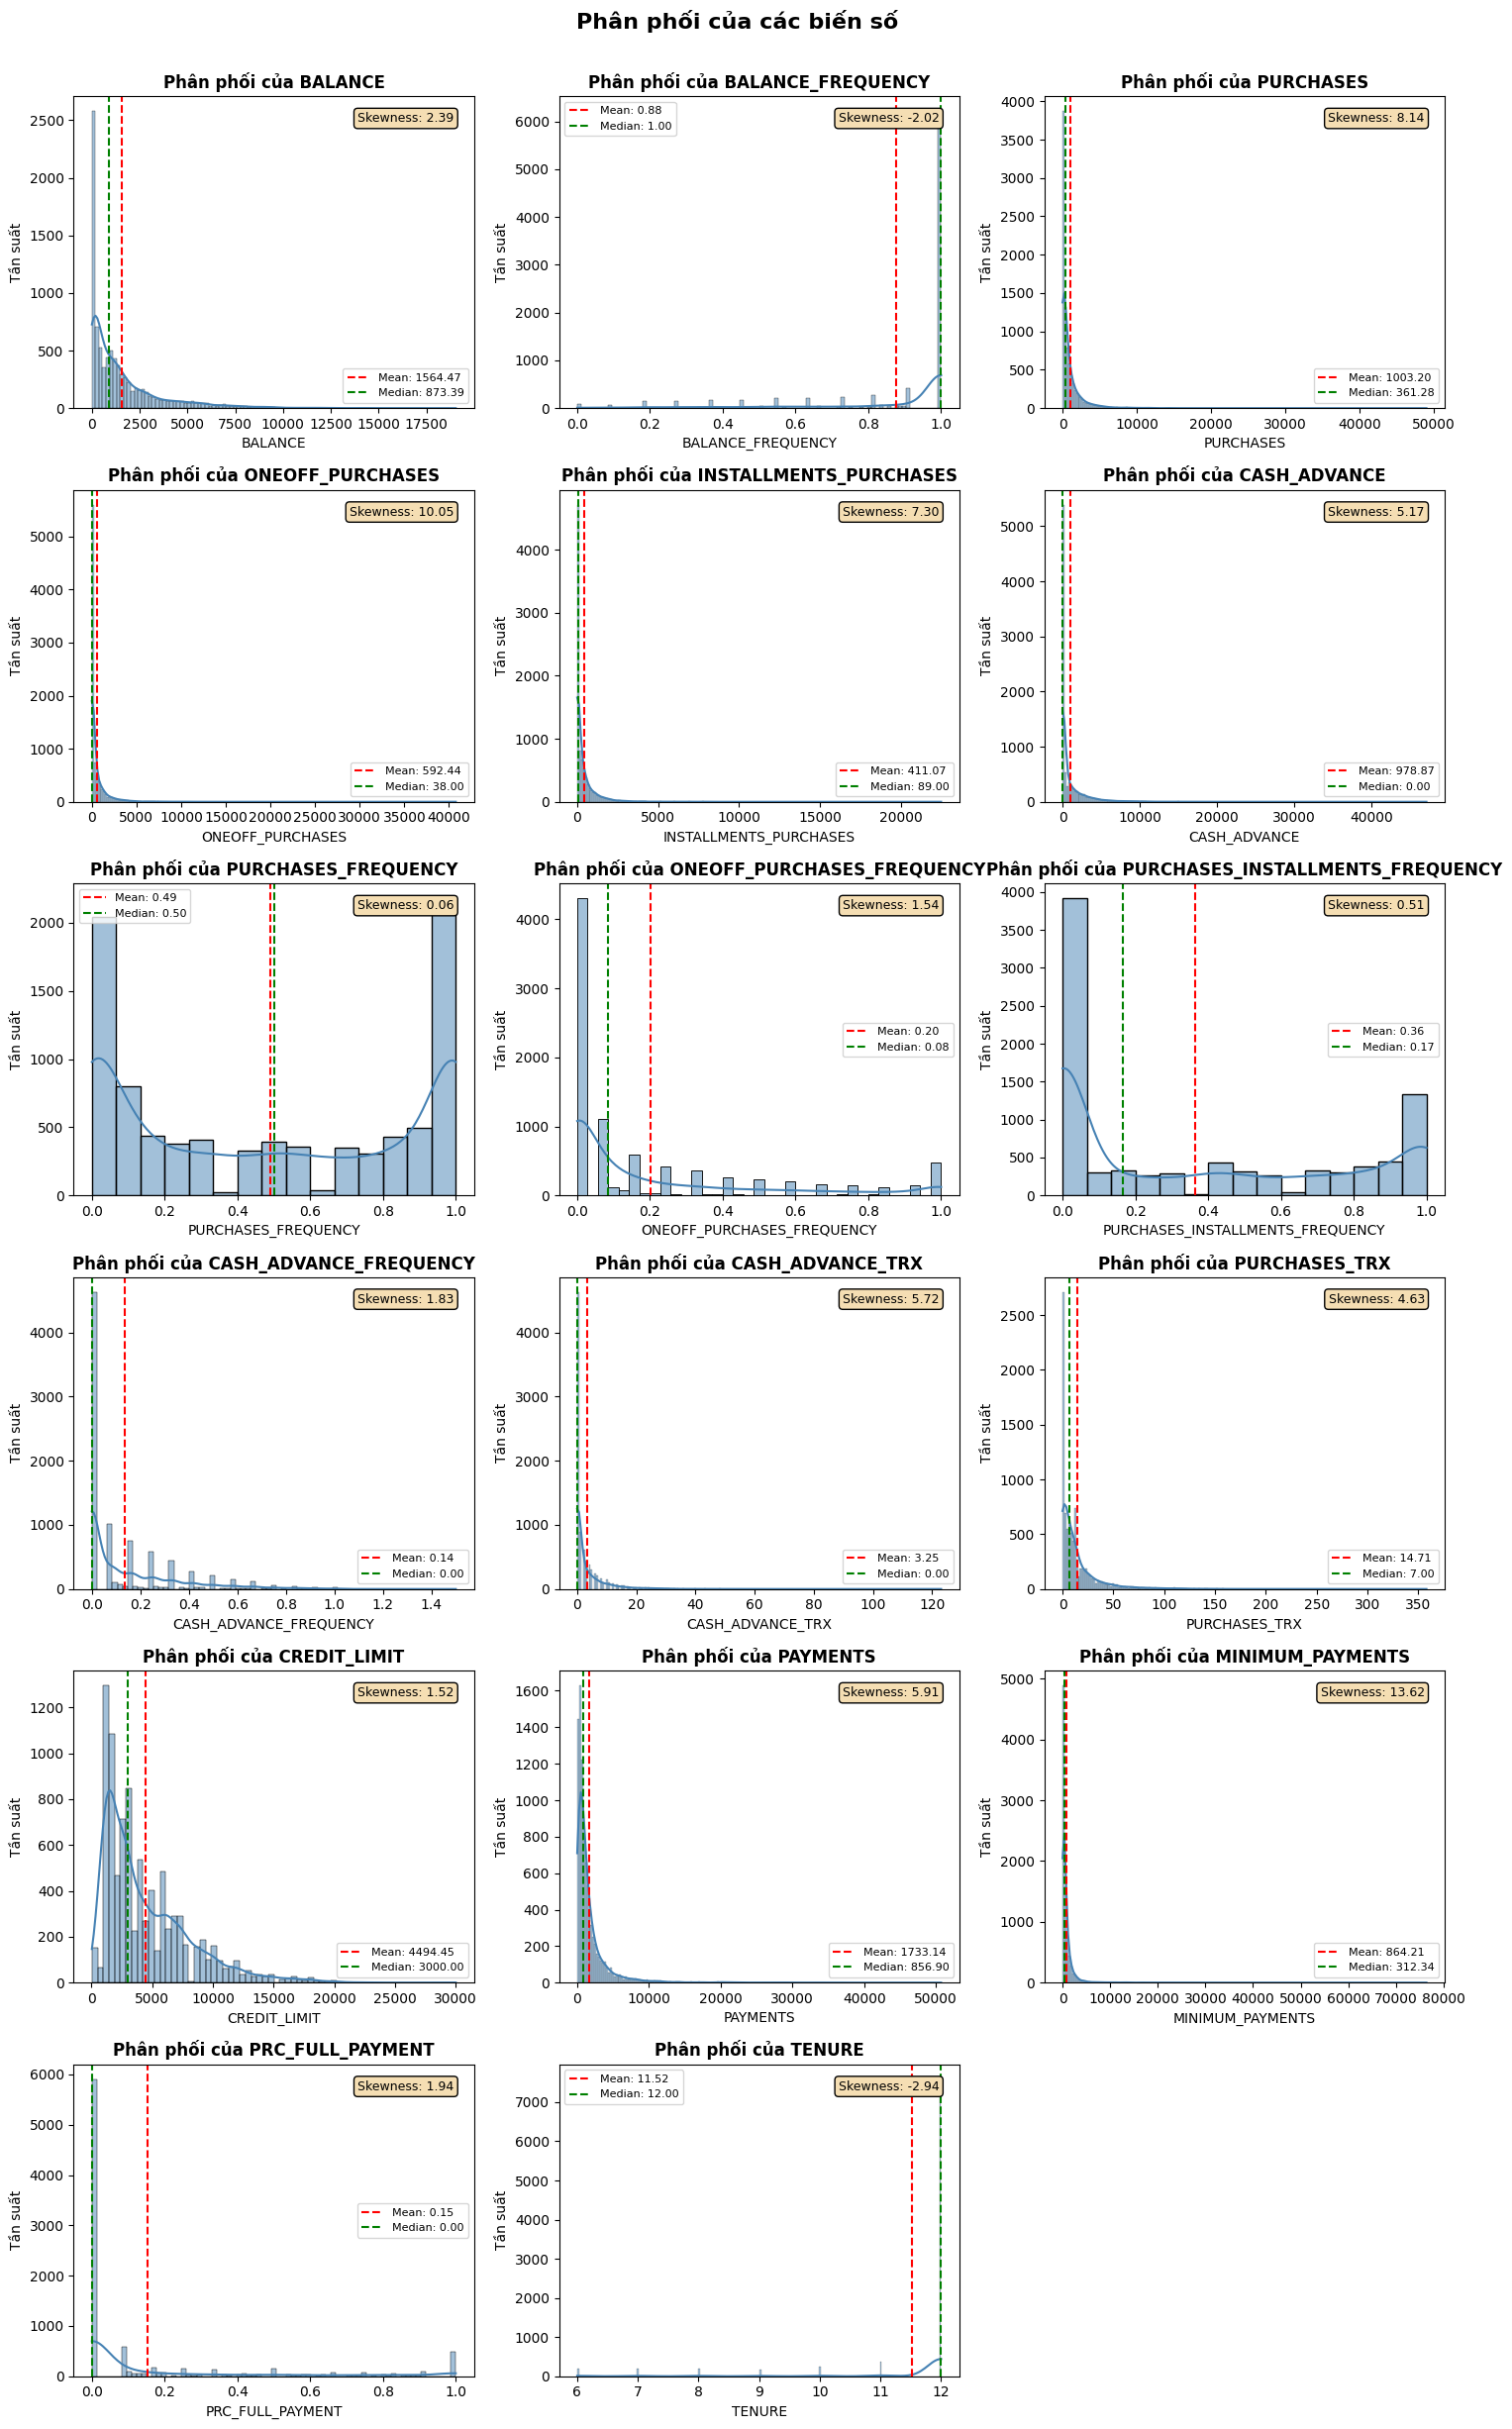


Độ lệch (Skewness) của các biến:
--------------------------------------------------
BALANCE                            :    2.393 - Lệch phải
BALANCE_FREQUENCY                  :   -2.023 - Lệch trái
PURCHASES                          :    8.144 - Lệch phải
ONEOFF_PURCHASES                   :   10.045 - Lệch phải
INSTALLMENTS_PURCHASES             :    7.299 - Lệch phải
CASH_ADVANCE                       :    5.167 - Lệch phải
PURCHASES_FREQUENCY                :    0.060 - Phân phối gần đối xứng
ONEOFF_PURCHASES_FREQUENCY         :    1.536 - Lệch phải
PURCHASES_INSTALLMENTS_FREQUENCY   :    0.509 - Lệch phải
CASH_ADVANCE_FREQUENCY             :    1.829 - Lệch phải
CASH_ADVANCE_TRX                   :    5.721 - Lệch phải
PURCHASES_TRX                      :    4.631 - Lệch phải
CREDIT_LIMIT                       :    1.522 - Lệch phải
PAYMENTS                           :    5.908 - Lệch phải
MINIMUM_PAYMENTS                   :   13.623 - Lệch phải
PRC_FULL_PAYMENT                

In [5]:
# Lấy các cột số (loại bỏ CUST_ID)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Tạo figure với nhiều subplot
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Vẽ histogram với KDE
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Phân phối của {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần suất')
    
    # Thêm thông tin skewness
    skew_val = df[col].skew()
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)
    ax.text(0.95, 0.95, f'Skewness: {skew_val:.2f}', transform=ax.transAxes, 
            ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat'))

# Ẩn các subplot thừa
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Phân phối của các biến số', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Hiển thị thông tin skewness
print("\nĐộ lệch (Skewness) của các biến:")
print("-" * 50)
for col in numeric_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        skew_type = "Phân phối gần đối xứng"
    elif skew > 0:
        skew_type = "Lệch phải"
    else:
        skew_type = "Lệch trái"
    print(f"{col:35s}: {skew:8.3f} - {skew_type}")

### **1.3 Ma trận tương quan**

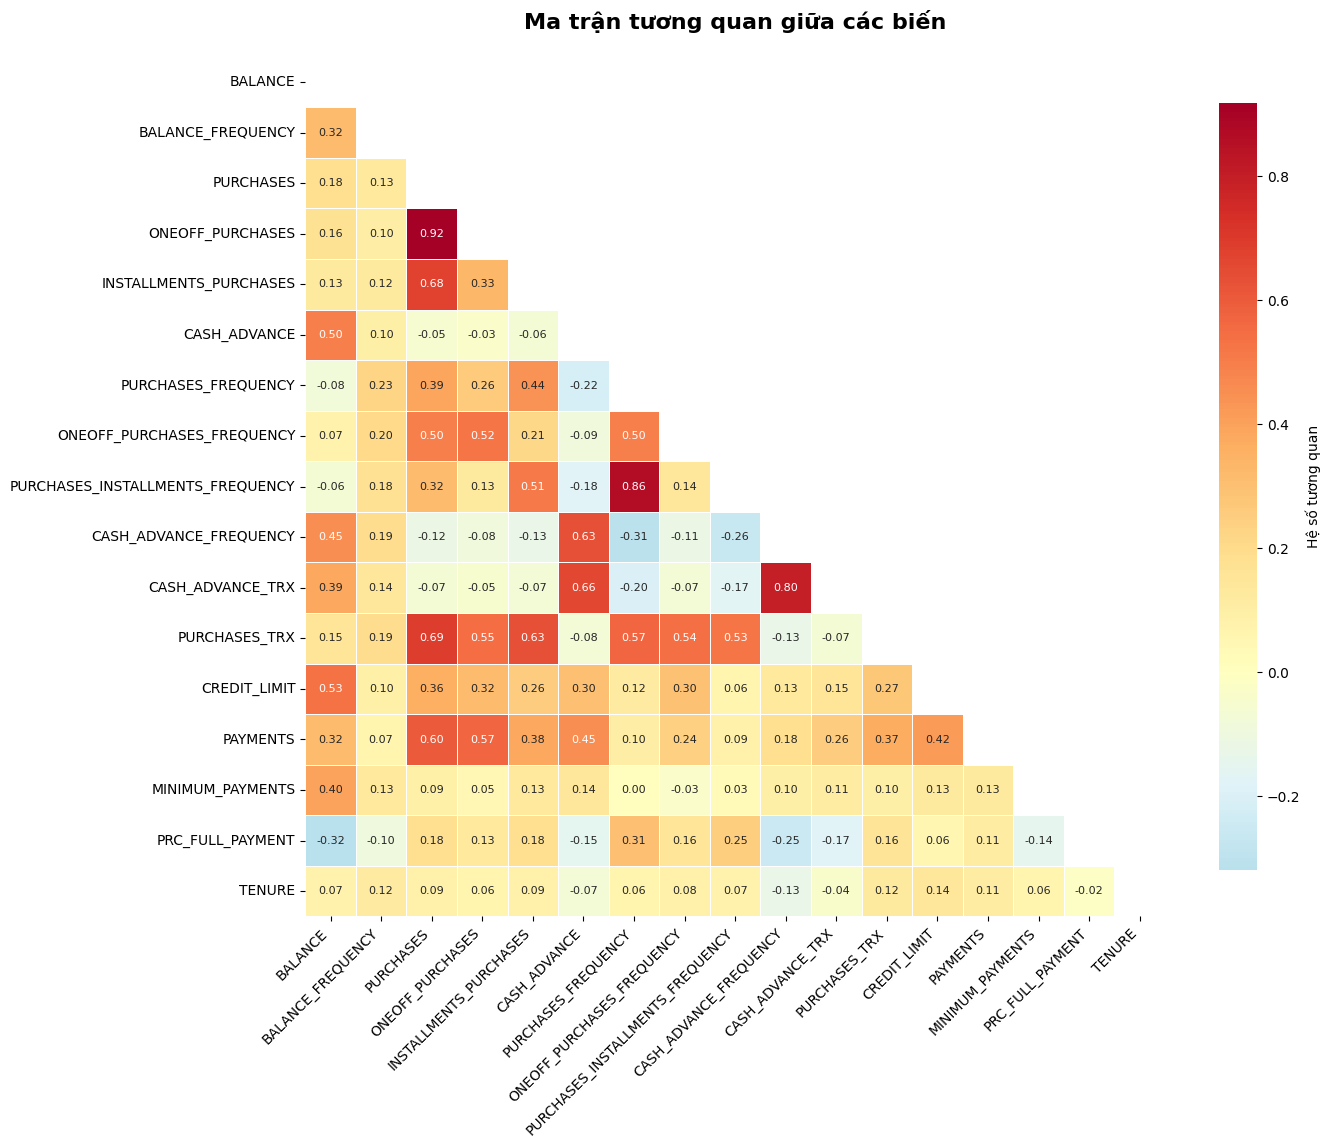


các cặp biến có tương quan CAO (|r| > 0.7):
------------------------------------------------------------


,Biến 1,Biến 2,Tương quan
0,PURCHASES,ONEOFF_PURCHASES,0.916845
1,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.862934
2,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.799561


In [6]:
# Tính ma trận tương quan (chỉ với các cột số)
df_numeric = df.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()

# Vẽ heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask nửa trên

sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdYlBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Hệ số tương quan"},
            annot_kws={"size": 8})

plt.title('Ma trận tương quan giữa các biến', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Tìm các cặp biến có tương quan cao
print("\ncác cặp biến có tương quan CAO (|r| > 0.7):")
print("-" * 60)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Biến 1': correlation_matrix.columns[i],
                'Biến 2': correlation_matrix.columns[j],
                'Tương quan': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Tương quan', ascending=False)
    display(high_corr_df)
else:
    print("Không có cặp biến nào có tương quan cao (|r| > 0.7)")

### **1.4 Phát hiện outliers**

Thống kê Outliers theo phương pháp IQR:
Biến                                 Số outliers    Tỷ lệ (%)   Giới hạn dưới   Giới hạn trên
--------------------------------------------------------------------------------
BALANCE                                      695        7.77%        -2760.51         4942.93
BALANCE_FREQUENCY                          1,493       16.68%            0.72            1.17
PURCHASES                                    808        9.03%        -1566.11         2715.87
ONEOFF_PURCHASES                           1,013       11.32%         -866.11         1443.51
INSTALLMENTS_PURCHASES                       867        9.69%         -702.96         1171.59
CASH_ADVANCE                               1,030       11.51%        -1670.73         2784.55
PURCHASES_FREQUENCY                            0        0.00%           -1.17            2.17
ONEOFF_PURCHASES_FREQUENCY                   782        8.74%           -0.45            0.75
PURCHASES_INSTALLMENTS_FREQUENCY 

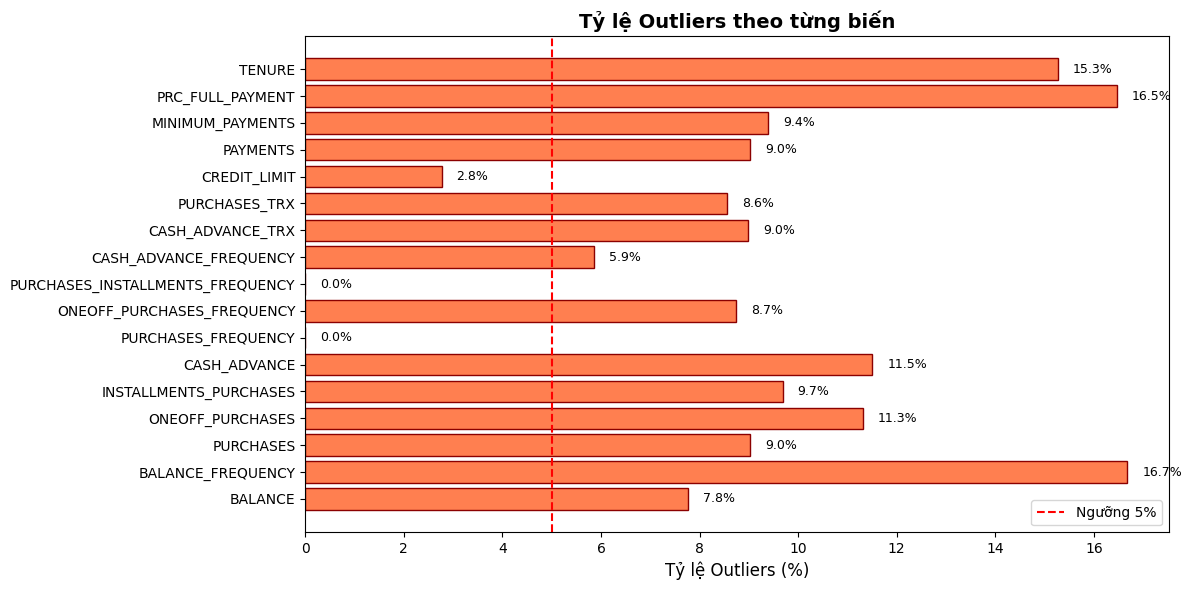

In [7]:
# Thống kê số lượng outliers theo phương pháp IQR
def count_outliers_iqr(df, column):
    """Đếm số outliers sử dụng phương pháp IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Thống kê Outliers theo phương pháp IQR:")
print("=" * 80)
print(f"{'Biến':<35} {'Số outliers':>12} {'Tỷ lệ (%)':>12} {'Giới hạn dưới':>15} {'Giới hạn trên':>15}")
print("-" * 80)

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = count_outliers_iqr(df, col)
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Biến': col,
        'Số outliers': n_outliers,
        'Tỷ lệ (%)': pct,
        'Giới hạn dưới': lower,
        'Giới hạn trên': upper
    })
    print(f"{col:<35} {n_outliers:>12,} {pct:>11.2f}% {lower:>15.2f} {upper:>15.2f}")

# Tạo biểu đồ tổng hợp outliers
outlier_df = pd.DataFrame(outlier_summary)
plt.figure(figsize=(12, 6))
bars = plt.barh(outlier_df['Biến'], outlier_df['Tỷ lệ (%)'], color='coral', edgecolor='darkred')
plt.xlabel('Tỷ lệ Outliers (%)', fontsize=12)
plt.title('Tỷ lệ Outliers theo từng biến', fontsize=14, fontweight='bold')
plt.axvline(x=5, color='red', linestyle='--', label='Ngưỡng 5%')
plt.legend()

# Thêm giá trị lên bars
for bar, val in zip(bars, outlier_df['Tỷ lệ (%)']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

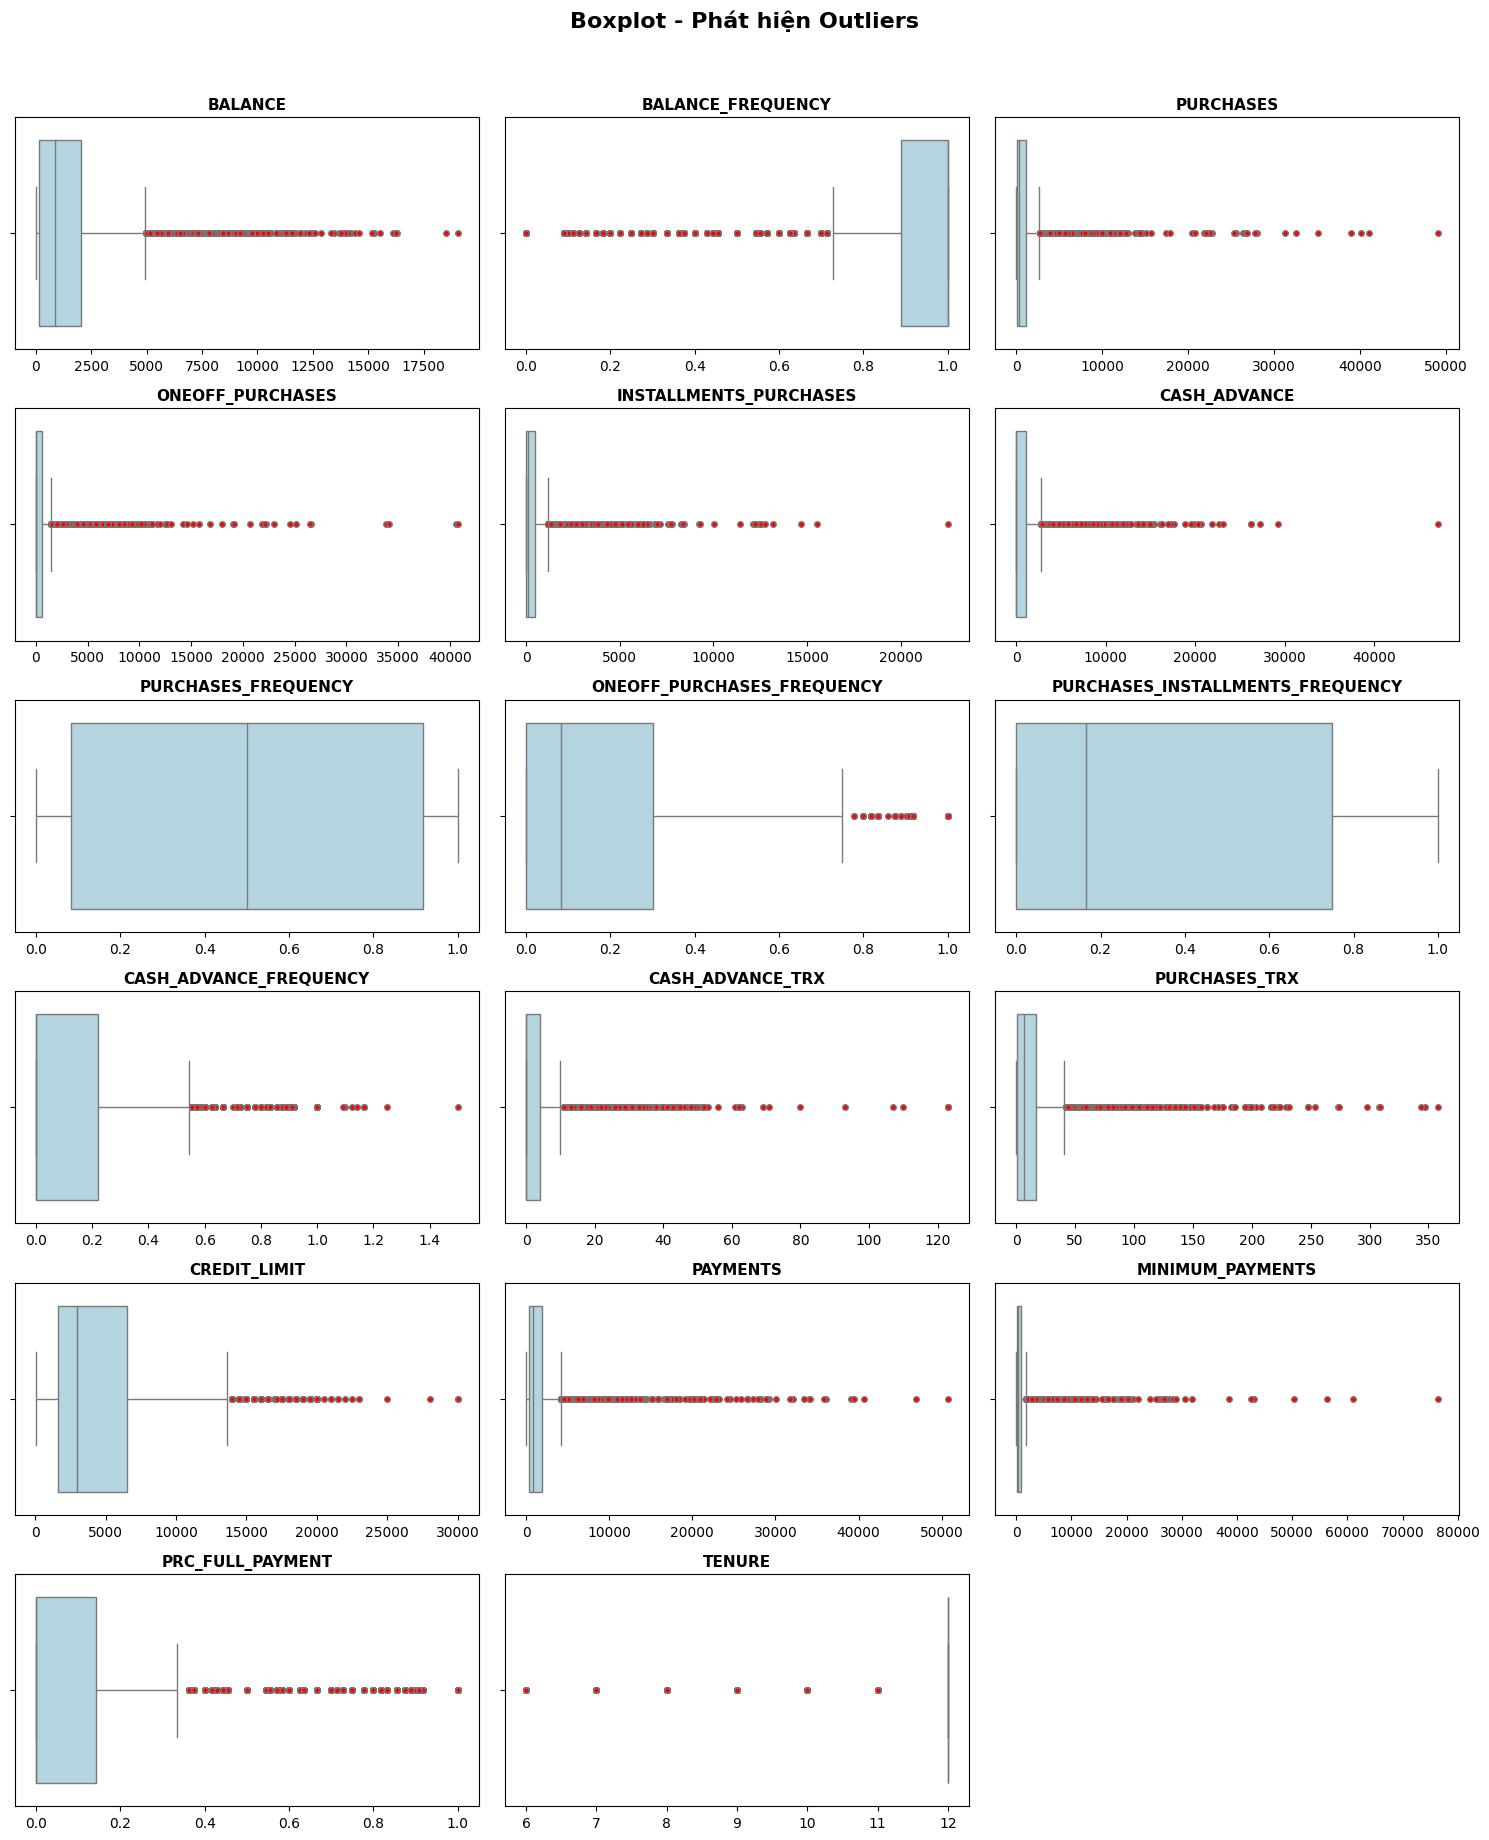

In [8]:
# Vẽ boxplot cho tất cả các biến số để phát hiện outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.boxplot(x=df[col], ax=ax, color='lightblue', flierprops=dict(markerfacecolor='red', marker='o', markersize=4))
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')

# Ẩn các subplot thừa
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplot - Phát hiện Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **2. TIỀN XỬ LÝ DỮ LIỆU**

### **2.1 Xử lý missing values**

### **2.2 Xử lý outliers**